# Domain Clustering — taxonomy evaluation

Evaluate whether the taxonomy in `category_hierarchy.json` fits the text of papers
in a chosen domain (`DOMAIN_INDEX` in the config cell). Default is the **next**
domain after Agricultural and Biological Sciences (**Arts and Humanities**).

## Preprocessing (aligned with NMF)

Same cleaning as `src.modeling.nmf_topic_modeling` / `text_cleaning.py`:

- strip Tamil/Sinhala (non-English script) tokens
- strip metadata boilerplate
- English + domain/corpus stop words (`CUSTOM_STOP_WORDS`: study/research/paper/results/methods, sri/lanka, the/of/to/were/was/in/with/is/for/as)
- drop any n-gram that still contains a stop token (so `sri lanka` cannot leak back in)
- `ngram_range=(1, 3)` (unigrams → trigrams)
- `norm="l2"`, `sublinear_tf=True`, `max_df=0.70`

## Three experiments

| # | Question | Method |
|---|----------|--------|
| 1 | Does the taxonomy match? | KMeans with *k* = #subdomains; **ARI**, **NMI** vs existing labels |
| 2 | How many groups naturally exist? | Sweep *k*; **silhouette**, **Calinski–Harabasz**, **Davies–Bouldin** |
| 3 | Is each subdomain suitable for its subfields? | Within each subdomain (not General): KMeans *k* = #leaf subfields; ARI/NMI + natural-*k* sweep |

**General** (`General Agricultural and Biological Sciences`) is excluded from primary
alignment metrics — it is a catch-all, not a coherent research group. We only check
where leftover "General" papers land after clustering (suitability of that residual).

**Outputs:** `./outputs/domain_clustering/<domain_slug>/`

In [59]:
import importlib
import src.preprocessing.text_cleaning as tc

importlib.reload(tc)

print(tc.__file__)
print(hasattr(tc, "ngram_contains_stopword"))
print([x for x in dir(tc) if "stopword" in x.lower()])


/home/asma/Projects/researchlanka-ai/backend/src/preprocessing/text_cleaning.py
True
['DOMAIN_STOPWORDS', 'FUNCTION_STOPWORDS', 'ngram_contains_stopword']


## 1. Setup

In [60]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import sparse
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.preprocessing import normalize

BACKEND_ROOT = Path("..").resolve()
sys.path.insert(0, str(BACKEND_ROOT))

from src.modeling.nmf_topic_modeling import TEXT_COLUMNS, combined_text
from src.preprocessing.text_cleaning import (
    CUSTOM_STOP_WORDS,
    cleaning_report,
    ngram_contains_stopword,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
RANDOM_STATE = 42

## 2. Configuration

In [61]:
TAXONOMY_PATH = BACKEND_ROOT / "category_hierarchy.json"
DATA_PATH = BACKEND_ROOT / "data/processed/common/common_publications_final_with_linearsvm.csv"
if not DATA_PATH.exists():
    DATA_PATH = BACKEND_ROOT / "data/processed/common/common_publications_final.csv"

# 0 = Agricultural and Biological Sciences, 1 = Arts and Humanities, ...
DOMAIN_INDEX = 6

STOP_WORDS = sorted(set(CUSTOM_STOP_WORDS))

DOMAIN_COLUMN = "primary_field"
SUBFIELD_COLUMN = "primary_subfield"

# NMF-aligned TF-IDF (max_df tightened to 70%)
TFIDF_KWARGS = dict(
    lowercase=True,
    stop_words=STOP_WORDS,
    strip_accents="unicode",
    ngram_range=(1, 3),
    min_df=5,
    max_df=0.70,
    sublinear_tf=True,
    norm="l2",
)

SVD_COMPONENTS = 100
SAMPLE_N = None  # e.g. 5000 for a quick smoke test
K_SWEEP_MAX = 15  # upper bound for natural-k experiment

print(f"Taxonomy: {TAXONOMY_PATH}")
print(f"Data:     {DATA_PATH}")
print(f"DOMAIN_INDEX={DOMAIN_INDEX}  stop_words={len(STOP_WORDS)}")
print(f"TF-IDF:   ngram={TFIDF_KWARGS['ngram_range']} max_df={TFIDF_KWARGS['max_df']} "
      f"norm={TFIDF_KWARGS['norm']} sublinear_tf={TFIDF_KWARGS['sublinear_tf']}")

Taxonomy: /home/asma/Projects/researchlanka-ai/backend/category_hierarchy.json
Data:     /home/asma/Projects/researchlanka-ai/backend/data/processed/common/common_publications_final_with_linearsvm.csv
DOMAIN_INDEX=6  stop_words=350
TF-IDF:   ngram=(1, 3) max_df=0.7 norm=l2 sublinear_tf=True


## 3. Load taxonomy — first domain (exclude General from primary evaluation)

In [62]:
with open(TAXONOMY_PATH, encoding="utf-8") as f:
    taxonomy = json.load(f)

domain_names = list(taxonomy)
TARGET_DOMAIN = domain_names[DOMAIN_INDEX]
print("Domains:")
for i, name in enumerate(domain_names):
    mark = " ← selected" if i == DOMAIN_INDEX else ""
    print(f"  [{i}] {name}{mark}")

OUTPUT_DIR = Path("./outputs/domain_clustering") / TARGET_DOMAIN.replace(" ", "_").lower()
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"\nOutput: {OUTPUT_DIR.resolve()}")

subdomain_map_all = taxonomy[TARGET_DOMAIN]  # {subdomain: [subfields]}

# Primary evaluation excludes catch-all "General"
GENERAL_KEY = "General"
subdomain_map = {k: v for k, v in subdomain_map_all.items() if k != GENERAL_KEY}

subfield_to_subdomain = {}
for subdomain, subfields in subdomain_map_all.items():
    for sf in subfields:
        subfield_to_subdomain[sf] = subdomain

eval_subfields = sorted(
    sf for subdomain, sfs in subdomain_map.items() for sf in sfs
)
n_subdomains = len(subdomain_map)
n_subfields = len(eval_subfields)

print(f"Target domain: {TARGET_DOMAIN}")
print(f"Subdomains for evaluation ({n_subdomains}): {list(subdomain_map)}")
print(f"Subfields for evaluation  ({n_subfields}): {eval_subfields}")
print(f"Excluded from primary eval: {GENERAL_KEY} → {subdomain_map_all.get(GENERAL_KEY)}")

pd.DataFrame([
    {"subdomain": sd, "subfield": sf, "evaluable": sd != GENERAL_KEY}
    for sd, sfs in subdomain_map_all.items()
    for sf in sfs
])

Domains:
  [0] Agricultural and Biological Sciences
  [1] Arts and Humanities
  [2] Biochemistry, Genetics and Molecular Biology
  [3] Business, Management and Accounting
  [4] Chemical Engineering
  [5] Chemistry
  [6] Computer Science ← selected
  [7] Decision Sciences
  [8] Dentistry
  [9] Earth and Planetary Sciences
  [10] Economics, Econometrics and Finance
  [11] Energy
  [12] Engineering
  [13] Environmental Science
  [14] Health Professions
  [15] Immunology and Microbiology
  [16] Materials Science
  [17] Mathematics
  [18] Medicine
  [19] Neuroscience
  [20] Nursing
  [21] Pharmacology, Toxicology and Pharmaceutics
  [22] Physics and Astronomy
  [23] Psychology
  [24] Social Sciences
  [25] Veterinary

Output: /home/asma/Projects/researchlanka-ai/backend/notebooks/outputs/domain_clustering/computer_science
Target domain: Computer Science
Subdomains for evaluation (6): ['AI & Machine Learning', 'Software & Systems', 'Networks & Security', 'Theory & Computation', 'Graphics & H

,subdomain,subfield,evaluable
0,AI & Machine Learning,Artificial Intelligence,True
1,AI & Machine Learning,Computer Vision and Pattern Recognition,True
2,Software & Systems,Software,True
3,Software & Systems,Hardware and Architecture,True
4,Software & Systems,Computer Science Applications,True
5,Networks & Security,Computer Networks and Communications,True
6,Theory & Computation,Computational Theory and Mathematics,True
7,Theory & Computation,Signal Processing,True
8,Graphics & HCI,Computer Graphics and Computer-Aided Design,True
9,Graphics & HCI,Human-Computer Interaction,True


## 4. Load corpus & filter to target domain

In [63]:
df_all = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Full corpus: {df_all.shape[0]:,} rows")

domain_mask = df_all[DOMAIN_COLUMN].fillna("").astype(str) == TARGET_DOMAIN
df = df_all.loc[domain_mask].copy()
if SAMPLE_N and len(df) > SAMPLE_N:
    df = df.sample(SAMPLE_N, random_state=RANDOM_STATE).reset_index(drop=True)

df["taxonomy_subdomain"] = df[SUBFIELD_COLUMN].map(subfield_to_subdomain)
df["is_general"] = df["taxonomy_subdomain"] == GENERAL_KEY
df["in_eval_taxonomy"] = df[SUBFIELD_COLUMN].isin(eval_subfields)

print(f"Rows in '{TARGET_DOMAIN}': {len(df):,}")
print(f"\nSubdomain distribution (incl. General / unmapped):")
print(df["taxonomy_subdomain"].fillna("(unmapped)").value_counts())
print(f"\nEval-taxonomy labeled (excl. General): {df['in_eval_taxonomy'].sum():,}")
print(f"General catch-all rows: {df['is_general'].sum():,}")

Full corpus: 147,859 rows
Rows in 'Computer Science': 5,242

Subdomain distribution (incl. General / unmapped):
taxonomy_subdomain
AI & Machine Learning    2511
Information Systems      1179
Networks & Security       609
Theory & Computation      354
Software & Systems        330
Graphics & HCI            259
Name: count, dtype: int64

Eval-taxonomy labeled (excl. General): 5,242
General catch-all rows: 0


## 5. Preprocess text (NMF cleaning) → TF-IDF → L2-normalized SVD

In [64]:
# combined_text(..., clean=True) strips non-Latin + boilerplate (same as NMF)
raw_texts = combined_text(df, TEXT_COLUMNS, clean=False)
report = cleaning_report(raw_texts)
print("Cleaning audit:", report)

texts = combined_text(df, TEXT_COLUMNS, clean=True)
has_text = texts.str.len() > 0
work = df.loc[has_text].copy().reset_index(drop=True)
texts = texts[has_text].reset_index(drop=True)
print(f"Usable text rows after cleaning: {len(work):,} / {len(df):,}")

vectorizer = TfidfVectorizer(**TFIDF_KWARGS)
X_tfidf = vectorizer.fit_transform(texts)
feature_names_all = vectorizer.get_feature_names_out()
stop_set = set(STOP_WORDS)
keep_idx = np.array(
    [i for i, term in enumerate(feature_names_all) if not ngram_contains_stopword(term, stop_set)],
    dtype=int,
)
n_dropped = len(feature_names_all) - len(keep_idx)
X_tfidf = X_tfidf[:, keep_idx]
print(f"TF-IDF: {X_tfidf.shape[0]:,} docs × {X_tfidf.shape[1]:,} features "
      f"(dropped {n_dropped:,} stop n-grams including sri/lanka and function words)")
print(f"Stop words: {len(STOP_WORDS)}")

n_comp = min(SVD_COMPONENTS, X_tfidf.shape[1] - 1, X_tfidf.shape[0] - 1)
svd = TruncatedSVD(n_components=n_comp, random_state=RANDOM_STATE)
X_embed = normalize(svd.fit_transform(X_tfidf), norm="l2")  # re-normalize after SVD
print(f"SVD embedding: {X_embed.shape}, explained variance: {svd.explained_variance_ratio_.sum():.3f}")

Cleaning audit: {'n_rows': 5242, 'rows_with_non_latin_chars': 3, 'rows_with_boilerplate_phrases': 11}
Usable text rows after cleaning: 5,242 / 5,242
TF-IDF: 5,242 docs × 16,058 features (dropped 0 stop n-grams including sri/lanka and function words)
Stop words: 350
SVD embedding: (5242, 100), explained variance: 0.241


## 6. Helpers

In [65]:
def cluster_kmeans(X: np.ndarray, k: int, random_state: int = RANDOM_STATE) -> np.ndarray:
    if k < 2 or len(X) < k:
        raise ValueError(f"Need at least k={k} samples, got {len(X)}")
    return KMeans(n_clusters=k, n_init=10, random_state=random_state).fit_predict(X)


def ari_nmi(y_true, y_pred) -> dict:
    """ARI / NMI on rows where y_true is non-null."""
    mask = pd.Series(y_true).notna().to_numpy()
    if mask.sum() < 2:
        return {"n": int(mask.sum()), "ari": np.nan, "nmi": np.nan}
    yt = pd.Series(y_true)[mask].astype(str).to_numpy()
    yp = np.asarray(y_pred)[mask]
    return {
        "n": int(mask.sum()),
        "ari": float(adjusted_rand_score(yt, yp)),
        "nmi": float(normalized_mutual_info_score(yt, yp, average_method="arithmetic")),
    }


def internal_scores(X: np.ndarray, labels: np.ndarray) -> dict:
    """Silhouette (↑), Calinski–Harabasz (↑), Davies–Bouldin (↓)."""
    n_labels = len(set(labels))
    if n_labels < 2 or n_labels >= len(X):
        return {"silhouette": np.nan, "calinski_harabasz": np.nan, "davies_bouldin": np.nan}
    return {
        "silhouette": float(silhouette_score(X, labels)),
        "calinski_harabasz": float(calinski_harabasz_score(X, labels)),
        "davies_bouldin": float(davies_bouldin_score(X, labels)),
    }


def sweep_k(X: np.ndarray, k_min: int, k_max: int) -> pd.DataFrame:
    rows = []
    for k in range(k_min, k_max + 1):
        if k < 2 or len(X) <= k:
            continue
        labels = cluster_kmeans(X, k)
        scores = internal_scores(X, labels)
        rows.append({"k": k, **scores})
    return pd.DataFrame(rows)


def pick_natural_k(sweep: pd.DataFrame) -> dict:
    """Vote across metrics: max silhouette, max CH, min DB."""
    if sweep.empty:
        return {"silhouette_best": None, "ch_best": None, "db_best": None, "consensus": None}
    sil_k = int(sweep.loc[sweep["silhouette"].idxmax(), "k"])
    ch_k = int(sweep.loc[sweep["calinski_harabasz"].idxmax(), "k"])
    db_k = int(sweep.loc[sweep["davies_bouldin"].idxmin(), "k"])
    votes = pd.Series([sil_k, ch_k, db_k]).value_counts()
    consensus = int(votes.index[0])
    return {"silhouette_best": sil_k, "ch_best": ch_k, "db_best": db_k, "consensus": consensus}


def top_terms_per_cluster(X: sparse.csr_matrix, labels: np.ndarray, feature_names, n_terms: int = 12) -> pd.DataFrame:
    rows = []
    for cid in sorted(set(labels)):
        idx = np.where(labels == cid)[0]
        centroid = np.asarray(X[idx].mean(axis=0)).ravel()
        top_idx = centroid.argsort()[-n_terms:][::-1]
        rows.append({
            "cluster": int(cid),
            "n_docs": int(len(idx)),
            "top_terms": ", ".join(feature_names[i] for i in top_idx),
        })
    return pd.DataFrame(rows)


def plot_confusion(y_true, y_pred, title: str, path: Path | None = None):
    mask = pd.Series(y_true).notna().to_numpy()
    yt = pd.Series(y_true)[mask].astype(str).to_numpy()
    yp = np.asarray(y_pred)[mask].astype(str)
    labels = sorted(set(yt) | set(yp))
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(yt, yp, labels=labels)
    cm_norm = cm.astype(float) / np.clip(cm.sum(axis=1, keepdims=True), 1, None)

    fig, axes = plt.subplots(1, 2, figsize=(max(12, len(labels) * 0.55), max(5, len(labels) * 0.4)))
    sns.heatmap(cm, xticklabels=labels, yticklabels=labels, cmap="Blues", ax=axes[0])
    axes[0].set_title(f"{title} — counts")
    axes[0].set_xlabel("Predicted cluster / name")
    axes[0].set_ylabel("Existing label")
    sns.heatmap(cm_norm, xticklabels=labels, yticklabels=labels, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1])
    axes[1].set_title(f"{title} — row-normalized")
    axes[1].set_xlabel("Predicted cluster / name")
    for ax in axes:
        ax.tick_params(axis="x", labelrotation=45, labelsize=8)
        ax.tick_params(axis="y", labelsize=8)
    plt.tight_layout()
    if path:
        plt.savefig(path, bbox_inches="tight")
    plt.show()


def verdict_ari(ari: float) -> str:
    if np.isnan(ari):
        return "insufficient labeled data"
    if ari >= 0.5:
        return "GOOD — taxonomy aligns with text clusters"
    if ari >= 0.2:
        return "PARTIAL — some groups match; review overlaps"
    return "POOR — taxonomy does not match text structure well"


feature_names = vectorizer.get_feature_names_out()

---
# Experiment 1 — Does the taxonomy match?

KMeans with **k = number of evaluable subdomains** (excluding General).
Compare cluster assignments to existing `taxonomy_subdomain` labels with **ARI** and **NMI**.

Also report ARI/NMI at **subfield** level (*k* = #leaf subfields, excl. General).

Experiment 1a — subdomain taxonomy match (excl. General)
  k = 6
  n: 5242
  ari: 0.1058
  nmi: 0.1808
  silhouette: 0.0541
  calinski_harabasz: 140.9688
  davies_bouldin: 3.9732
  → POOR — taxonomy does not match text structure well

Cluster → dominant taxonomy subdomain:
cluster_subdomain
0      Information Systems
1    AI & Machine Learning
2    AI & Machine Learning
3    AI & Machine Learning
4    AI & Machine Learning
5      Information Systems
Name: taxonomy_subdomain, dtype: str


,cluster,n_docs,top_terms
0,0,747,"security, blockchain, computer security, detec..."
1,1,1145,"computing, network, engineering, cloud, optimi..."
2,2,1198,"recognition, image, artificial, learning, arti..."
3,3,712,"natural language, natural, language, language ..."
4,4,1159,"education, learning, psychology, social, onlin..."
5,5,281,"software, software engineering, engineering, s..."


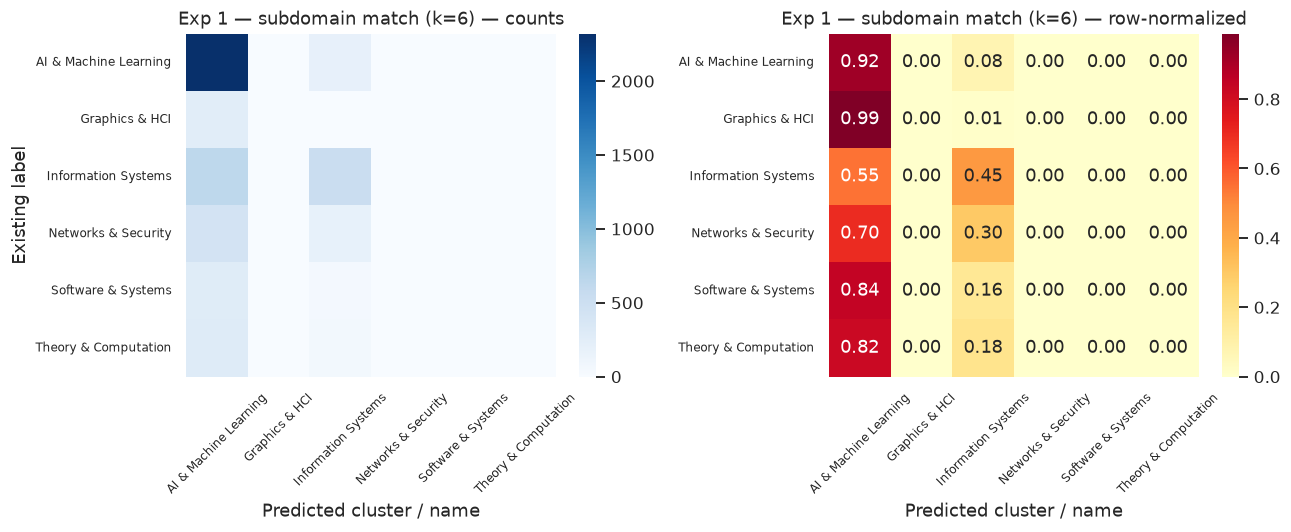

In [66]:
# --- Subdomain-level match ---
subdomain_clusters = cluster_kmeans(X_embed, k=n_subdomains)
work["cluster_subdomain"] = subdomain_clusters

# Evaluate only on non-General labeled rows
eval_mask = work["taxonomy_subdomain"].isin(subdomain_map.keys())
exp1_subdomain = ari_nmi(
    work.loc[eval_mask, "taxonomy_subdomain"],
    work.loc[eval_mask, "cluster_subdomain"],
)
exp1_subdomain_internal = internal_scores(X_embed[eval_mask.to_numpy()], subdomain_clusters[eval_mask.to_numpy()])

print("Experiment 1a — subdomain taxonomy match (excl. General)")
print(f"  k = {n_subdomains}")
for k, v in {**exp1_subdomain, **exp1_subdomain_internal}.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"  → {verdict_ari(exp1_subdomain['ari'])}")

# Cluster id → dominant existing subdomain (for readable confusion)
cluster_to_name = (
    work.loc[eval_mask]
    .groupby("cluster_subdomain")["taxonomy_subdomain"]
    .agg(lambda s: s.mode().iloc[0] if len(s) else "unknown")
)
work["cluster_subdomain_name"] = work["cluster_subdomain"].map(cluster_to_name)
print("\nCluster → dominant taxonomy subdomain:")
print(cluster_to_name)

subdomain_terms = top_terms_per_cluster(X_tfidf, subdomain_clusters, feature_names)
subdomain_terms.to_csv(OUTPUT_DIR / "exp1_subdomain_top_terms.csv", index=False)
display(subdomain_terms)

plot_confusion(
    work.loc[eval_mask, "taxonomy_subdomain"],
    work.loc[eval_mask, "cluster_subdomain_name"],
    f"Exp 1 — subdomain match (k={n_subdomains})",
    OUTPUT_DIR / "exp1_subdomain_confusion.png",
)

Experiment 1b — subfield taxonomy match (excl. General)
  k = 11
  n: 5242
  ari: 0.1601
  nmi: 0.3043
  silhouette: 0.0720
  calinski_harabasz: 121.2127
  davies_bouldin: 3.4259
  → POOR — taxonomy does not match text structure well


,cluster,n_docs,top_terms
0,0,300,"cloud, computing, cloud computing, resource, e..."
1,1,265,"software, software engineering, engineering, s..."
2,2,562,"natural language, natural, language, language ..."
3,3,770,"image, recognition, artificial, learning, visi..."
4,4,405,"education, learning, online, educational, onli..."
5,5,351,"detection, security, intrusion, intrusion dete..."
6,6,789,"web, business, social, management, wide web, w..."
7,7,907,"optimization, algorithms, network, algorithm, ..."
8,8,255,"blockchain, blockchain technology, security, b..."
9,9,392,"interaction, human, computer interaction, huma..."


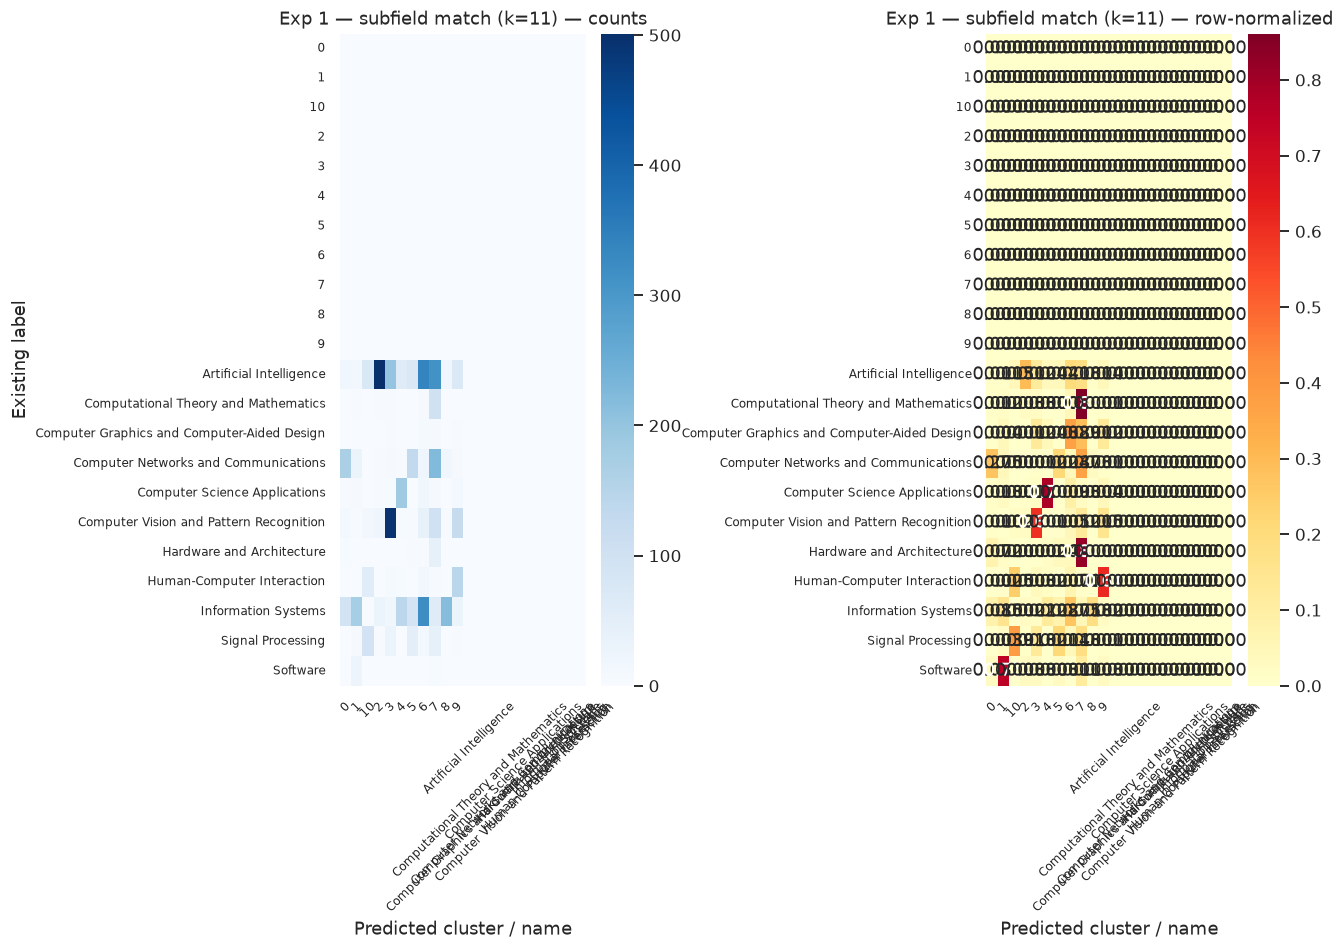

In [67]:
# --- Subfield-level match (excl. General leaf) ---
subfield_clusters = cluster_kmeans(X_embed, k=n_subfields)
work["cluster_subfield"] = subfield_clusters

sf_mask = work["in_eval_taxonomy"]
exp1_subfield = ari_nmi(
    work.loc[sf_mask, SUBFIELD_COLUMN],
    work.loc[sf_mask, "cluster_subfield"],
)
exp1_subfield_internal = internal_scores(
    X_embed[sf_mask.to_numpy()], subfield_clusters[sf_mask.to_numpy()]
)

print("Experiment 1b — subfield taxonomy match (excl. General)")
print(f"  k = {n_subfields}")
for k, v in {**exp1_subfield, **exp1_subfield_internal}.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")
print(f"  → {verdict_ari(exp1_subfield['ari'])}")

subfield_terms = top_terms_per_cluster(X_tfidf, subfield_clusters, feature_names)
subfield_terms.to_csv(OUTPUT_DIR / "exp1_subfield_top_terms.csv", index=False)
display(subfield_terms)

if sf_mask.sum() > 0:
    plot_confusion(
        work.loc[sf_mask, SUBFIELD_COLUMN],
        work.loc[sf_mask, "cluster_subfield"].astype(str),
        f"Exp 1 — subfield match (k={n_subfields})",
        OUTPUT_DIR / "exp1_subfield_confusion.png",
    )

In [68]:
# Where do "General" papers land under subdomain clustering?
general_mask = work["is_general"]
if general_mask.any():
    print(f"General papers: {general_mask.sum():,}")
    print("Where they land (cluster → dominant subdomain):")
    print(
        work.loc[general_mask, "cluster_subdomain_name"]
        .fillna("(unmapped cluster)")
        .value_counts()
    )
    print("\n→ If General spreads across many clusters, it is not a coherent group;")
    print("  if it concentrates in one cluster, that residual may deserve a real label.")
else:
    print("No General-labeled rows in this domain subset.")

No General-labeled rows in this domain subset.


---
# Experiment 2 — How many groups naturally exist?

Sweep *k* on the full domain embedding (all papers in the domain, including General / unmapped).

| Metric | Direction | Meaning |
|--------|-----------|--------|
| **Silhouette** | ↑ higher | Separation / cohesion |
| **Calinski–Harabasz** | ↑ higher | Between/within variance ratio |
| **Davies–Bouldin** | ↓ lower | Average similarity of each cluster to its nearest neighbour |

Compare the metric-chosen *k* to taxonomy *k* (subdomains / subfields).

In [69]:
k_min = 2
k_max = min(K_SWEEP_MAX, len(work) - 1)
sweep_df = sweep_k(X_embed, k_min, k_max)
natural = pick_natural_k(sweep_df)

print("Natural-k votes:")
print(f"  silhouette best k:       {natural['silhouette_best']}")
print(f"  Calinski–Harabasz best:  {natural['ch_best']}")
print(f"  Davies–Bouldin best:     {natural['db_best']}")
print(f"  consensus:               {natural['consensus']}")
print(f"\nTaxonomy subdomain k (excl. General): {n_subdomains}")
print(f"Taxonomy subfield  k (excl. General): {n_subfields}")

sweep_df.to_csv(OUTPUT_DIR / "exp2_k_sweep.csv", index=False)
sweep_df

Natural-k votes:
  silhouette best k:       15
  Calinski–Harabasz best:  2
  Davies–Bouldin best:     15
  consensus:               15

Taxonomy subdomain k (excl. General): 6
Taxonomy subfield  k (excl. General): 11


,k,silhouette,calinski_harabasz,davies_bouldin
0,2,0.032862,184.254254,5.002577
1,3,0.035518,166.371945,4.648289
2,4,0.044064,156.105197,4.482214
3,5,0.048656,148.301722,4.049026
4,6,0.054142,140.968849,3.973189
5,7,0.057511,134.108467,4.004482
6,8,0.061467,129.922149,3.670026
7,9,0.065979,125.623385,3.629945
8,10,0.070745,124.698640,3.498176
9,11,0.071997,121.212659,3.425851


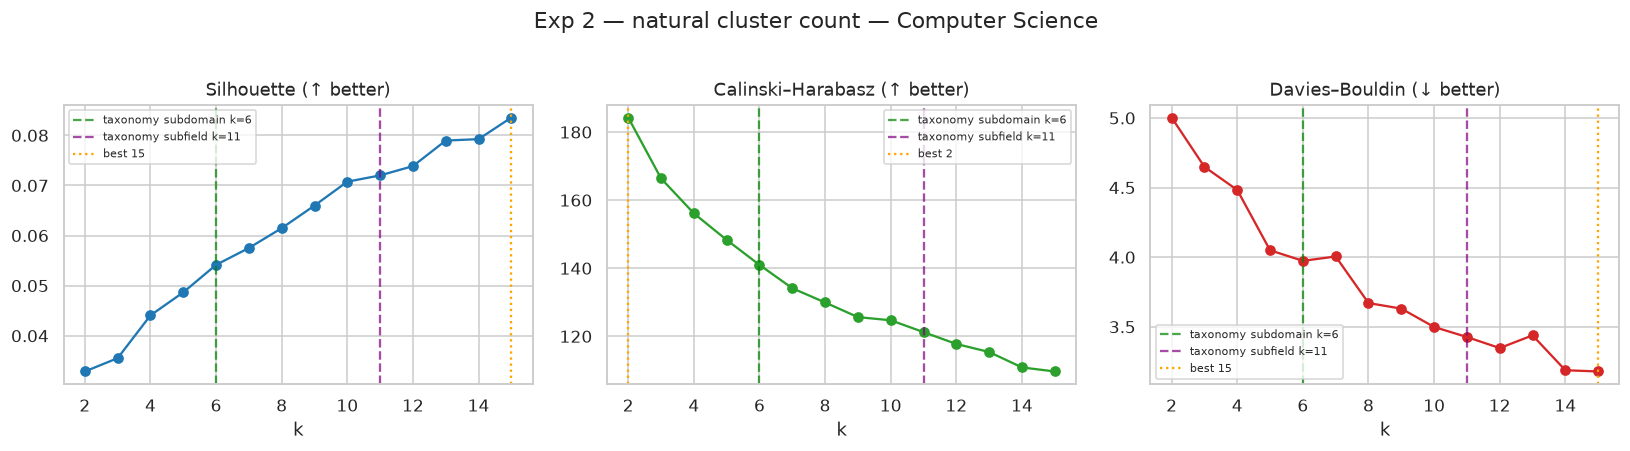

→ Natural consensus k=15 differs from taxonomy (subdomain=6, subfield=11).


In [70]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
specs = [
    ("silhouette", "Silhouette (↑ better)", "tab:blue", natural["silhouette_best"]),
    ("calinski_harabasz", "Calinski–Harabasz (↑ better)", "tab:green", natural["ch_best"]),
    ("davies_bouldin", "Davies–Bouldin (↓ better)", "tab:red", natural["db_best"]),
]
for ax, (col, title, color, best) in zip(axes, specs):
    ax.plot(sweep_df["k"], sweep_df[col], marker="o", color=color)
    ax.axvline(n_subdomains, color="green", linestyle="--", alpha=0.7, label=f"taxonomy subdomain k={n_subdomains}")
    ax.axvline(n_subfields, color="purple", linestyle="--", alpha=0.7, label=f"taxonomy subfield k={n_subfields}")
    if best is not None:
        ax.axvline(best, color="orange", linestyle=":", label=f"best {best}")
    ax.set_xlabel("k")
    ax.set_title(title)
    ax.legend(fontsize=7)

plt.suptitle(f"Exp 2 — natural cluster count — {TARGET_DOMAIN}", y=1.02)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "exp2_k_sweep.png", bbox_inches="tight")
plt.show()

if natural["consensus"] not in (n_subdomains, n_subfields):
    print(f"→ Natural consensus k={natural['consensus']} differs from taxonomy "
          f"(subdomain={n_subdomains}, subfield={n_subfields}).")
else:
    print(f"→ Natural consensus k={natural['consensus']} matches a taxonomy level.")

---
# Experiment 3 — Within each subdomain: are subfield groupings suitable?

For **each evaluable subdomain** (not General):

1. Restrict to papers labeled with that subdomain.
2. **Match test:** KMeans with *k* = #leaf subfields in the taxonomy for that subdomain → ARI / NMI.
3. **Natural-*k* test:** silhouette / Calinski–Harabasz / Davies–Bouldin sweep — does the taxonomy leaf count match what the text supports?

Subdomains with only **one** leaf (e.g. Food Science) cannot be split-tested for ARI;
we still note their size and skip the multi-cluster match.

In [71]:
within_rows = []
within_sweeps = {}

for subdomain, subfields in subdomain_map.items():
    k_tax = len(subfields)
    sub = work[work["taxonomy_subdomain"] == subdomain].copy()
    n_docs = len(sub)

    row = {
        "subdomain": subdomain,
        "taxonomy_k": k_tax,
        "n_docs": n_docs,
        "n_labeled_subfields": int(sub[SUBFIELD_COLUMN].isin(subfields).sum()),
        "ari": np.nan,
        "nmi": np.nan,
        "silhouette_at_tax_k": np.nan,
        "ch_at_tax_k": np.nan,
        "db_at_tax_k": np.nan,
        "natural_k_consensus": None,
        "silhouette_best_k": None,
        "ch_best_k": None,
        "db_best_k": None,
        "tax_k_matches_natural": None,
        "verdict": None,
        "note": "",
    }

    if k_tax < 2:
        row["note"] = "single leaf — no subfield split to validate"
        row["verdict"] = "N/A (1 subfield)"
        within_rows.append(row)
        print(f"\n[{subdomain}] k_tax=1, n={n_docs} — skip split test (single leaf).")
        continue

    if n_docs < k_tax + 1:
        row["note"] = f"too few docs ({n_docs}) for k={k_tax}"
        row["verdict"] = "insufficient data"
        within_rows.append(row)
        print(f"\n[{subdomain}] skip — only {n_docs} docs (need > {k_tax}).")
        continue

    pos = work.index.get_indexer(sub.index)
    X_sub = X_embed[pos]

    # Match: k = taxonomy leaf count
    labels = cluster_kmeans(X_sub, k=k_tax)
    label_map = dict(zip(sub.index, labels))
    col = "cluster_within_" + subdomain.replace(" ", "_").replace("&", "and")
    work.loc[sub.index, col] = labels

    labeled_sub = sub[sub[SUBFIELD_COLUMN].isin(subfields)]
    if len(labeled_sub) >= 2 and len({label_map[i] for i in labeled_sub.index}) > 1:
        y_true = labeled_sub[SUBFIELD_COLUMN].astype(str).to_numpy()
        y_pred = np.array([label_map[i] for i in labeled_sub.index])
        m = ari_nmi(y_true, y_pred)
        row["ari"] = m["ari"]
        row["nmi"] = m["nmi"]

    scores = internal_scores(X_sub, labels)
    row["silhouette_at_tax_k"] = scores["silhouette"]
    row["ch_at_tax_k"] = scores["calinski_harabasz"]
    row["db_at_tax_k"] = scores["davies_bouldin"]

    # Natural-k sweep within this subdomain
    k_hi = min(max(k_tax + 3, 6), n_docs - 1, 10)
    sub_sweep = sweep_k(X_sub, 2, k_hi)
    within_sweeps[subdomain] = sub_sweep
    nat = pick_natural_k(sub_sweep)
    row["natural_k_consensus"] = nat["consensus"]
    row["silhouette_best_k"] = nat["silhouette_best"]
    row["ch_best_k"] = nat["ch_best"]
    row["db_best_k"] = nat["db_best"]
    row["tax_k_matches_natural"] = nat["consensus"] == k_tax

    # Combined verdict: ARI alignment + natural-k agreement
    ari_ok = (not np.isnan(row["ari"])) and row["ari"] >= 0.2
    k_ok = bool(row["tax_k_matches_natural"])
    if ari_ok and k_ok:
        row["verdict"] = "SUITABLE — subfields match text & natural k"
    elif ari_ok:
        row["verdict"] = "PARTIAL — labels align somewhat, but natural k differs"
    elif k_ok:
        row["verdict"] = "PARTIAL — natural k matches taxonomy, but ARI weak"
    else:
        row["verdict"] = "NOT SUITABLE — consider merging/splitting subfields"

    within_rows.append(row)

    print(f"\n[{subdomain}] n={n_docs}, taxonomy_k={k_tax}")
    print(f"  ARI={row['ari']:.3f}  NMI={row['nmi']:.3f}" if not np.isnan(row["ari"]) else "  ARI/NMI: n/a")
    print(f"  at tax k — sil={row['silhouette_at_tax_k']:.3f}  CH={row['ch_at_tax_k']:.1f}  DB={row['db_at_tax_k']:.3f}")
    print(f"  natural k consensus={row['natural_k_consensus']} (sil={row['silhouette_best_k']}, "
          f"CH={row['ch_best_k']}, DB={row['db_best_k']})")
    print(f"  → {row['verdict']}")

    # Top terms for this within-subdomain clustering
    X_sub_tfidf = X_tfidf[pos]
    terms = top_terms_per_cluster(X_sub_tfidf, labels, feature_names)
    terms.insert(0, "subdomain", subdomain)
    terms.to_csv(
        OUTPUT_DIR / f"exp3_terms_{subdomain.replace(' ', '_').replace('&', 'and')}.csv",
        index=False,
    )

within_df = pd.DataFrame(within_rows)
within_df.to_csv(OUTPUT_DIR / "exp3_within_subdomain.csv", index=False)
within_df


[AI & Machine Learning] n=2511, taxonomy_k=2
  ARI=-0.023  NMI=0.101
  at tax k — sil=0.045  CH=148.4  DB=3.416
  natural k consensus=2 (sil=6, CH=2, DB=2)
  → PARTIAL — natural k matches taxonomy, but ARI weak

[Software & Systems] n=330, taxonomy_k=3
  ARI=0.611  NMI=0.609
  at tax k — sil=0.164  CH=41.0  DB=2.345
  natural k consensus=3 (sil=3, CH=2, DB=5)
  → SUITABLE — subfields match text & natural k

[Networks & Security] k_tax=1, n=609 — skip split test (single leaf).

[Theory & Computation] n=354, taxonomy_k=2
  ARI=0.034  NMI=0.232
  at tax k — sil=0.111  CH=47.5  DB=2.321
  natural k consensus=6 (sil=6, CH=3, DB=6)
  → NOT SUITABLE — consider merging/splitting subfields

[Graphics & HCI] n=259, taxonomy_k=2
  ARI=-0.042  NMI=0.094
  at tax k — sil=0.163  CH=53.1  DB=2.000
  natural k consensus=3 (sil=4, CH=3, DB=3)
  → NOT SUITABLE — consider merging/splitting subfields

[Information Systems] k_tax=1, n=1179 — skip split test (single leaf).


,subdomain,taxonomy_k,n_docs,n_labeled_subfields,ari,nmi,silhouette_at_tax_k,ch_at_tax_k,db_at_tax_k,natural_k_consensus,silhouette_best_k,ch_best_k,db_best_k,tax_k_matches_natural,verdict,note
0,AI & Machine Learning,2,2511,2511,-0.023272,0.101316,0.045277,148.388854,3.415631,2.0,6.0,2.0,2.0,True,"PARTIAL — natural k matches taxonomy, but ARI ...",
1,Software & Systems,3,330,330,0.610592,0.609419,0.163578,41.031668,2.345465,3.0,3.0,2.0,5.0,True,SUITABLE — subfields match text & natural k,
2,Networks & Security,1,609,609,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,N/A (1 subfield),single leaf — no subfield split to validate
3,Theory & Computation,2,354,354,0.034156,0.231766,0.110838,47.521423,2.320997,6.0,6.0,3.0,6.0,False,NOT SUITABLE — consider merging/splitting subf...,
4,Graphics & HCI,2,259,259,-0.042173,0.094347,0.162695,53.109929,1.999808,3.0,4.0,3.0,3.0,False,NOT SUITABLE — consider merging/splitting subf...,
5,Information Systems,1,1179,1179,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,None,N/A (1 subfield),single leaf — no subfield split to validate


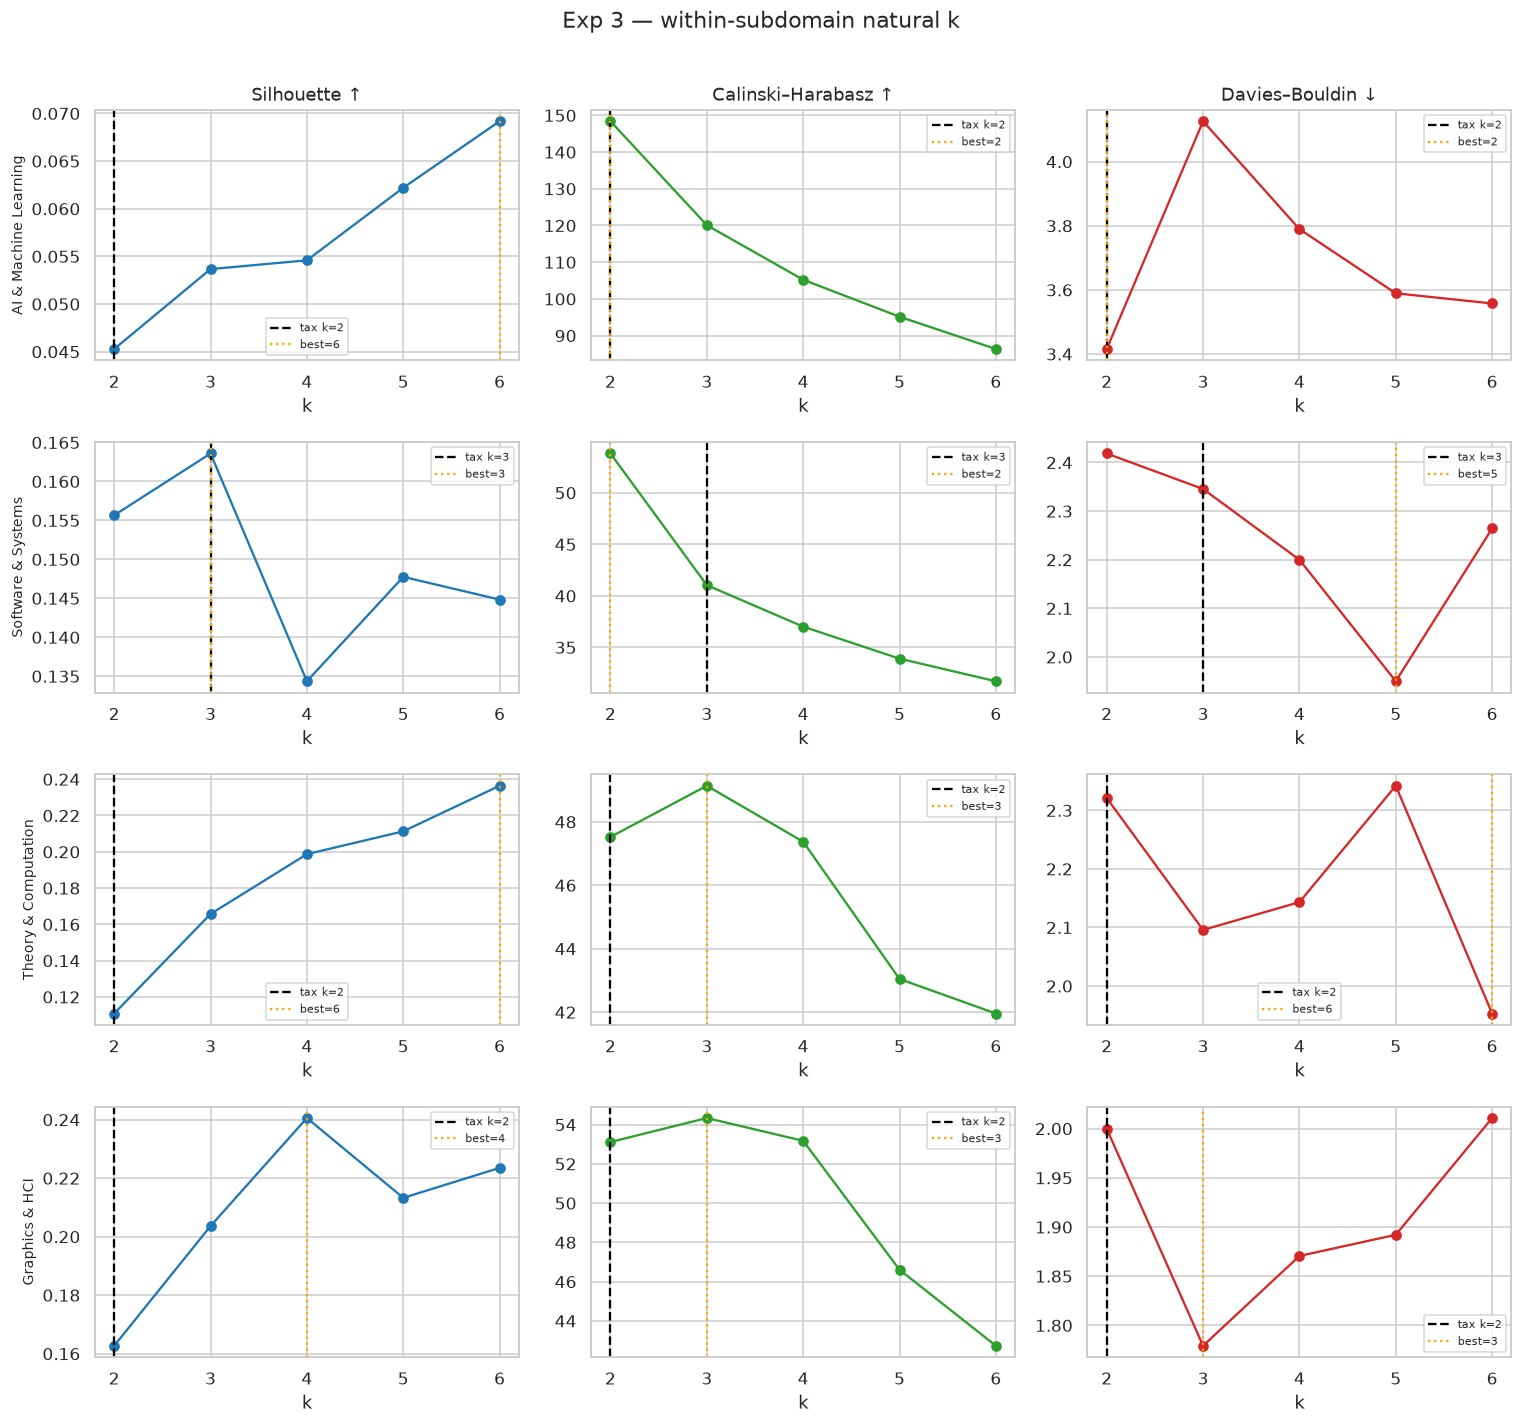

In [72]:
# Plot natural-k sweeps per multi-leaf subdomain
plot_items = [(sd, sw) for sd, sw in within_sweeps.items() if not sw.empty]
if not plot_items:
    print("No within-subdomain sweeps to plot.")
else:
    n = len(plot_items)
    fig, axes = plt.subplots(n, 3, figsize=(14, 3.2 * n), squeeze=False)
    for r, (subdomain, sw) in enumerate(plot_items):
        k_tax = len(subdomain_map[subdomain])
        nat = pick_natural_k(sw)
        for c, (col, title, color, best) in enumerate([
            ("silhouette", "Silhouette ↑", "tab:blue", nat["silhouette_best"]),
            ("calinski_harabasz", "Calinski–Harabasz ↑", "tab:green", nat["ch_best"]),
            ("davies_bouldin", "Davies–Bouldin ↓", "tab:red", nat["db_best"]),
        ]):
            ax = axes[r][c]
            ax.plot(sw["k"], sw[col], marker="o", color=color)
            ax.axvline(k_tax, color="black", linestyle="--", label=f"tax k={k_tax}")
            if best is not None:
                ax.axvline(best, color="orange", linestyle=":", label=f"best={best}")
            if c == 0:
                ax.set_ylabel(subdomain, fontsize=9)
            ax.set_title(title if r == 0 else "")
            ax.legend(fontsize=7)
            ax.set_xlabel("k")
    plt.suptitle("Exp 3 — within-subdomain natural k", y=1.01)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "exp3_within_k_sweeps.png", bbox_inches="tight")
    plt.show()

## Optional: confusion within a multi-leaf subdomain

Pick one subdomain to inspect leaf-level confusion (edit `INSPECT_SUBDOMAIN`).

Inspecting: AI & Machine Learning


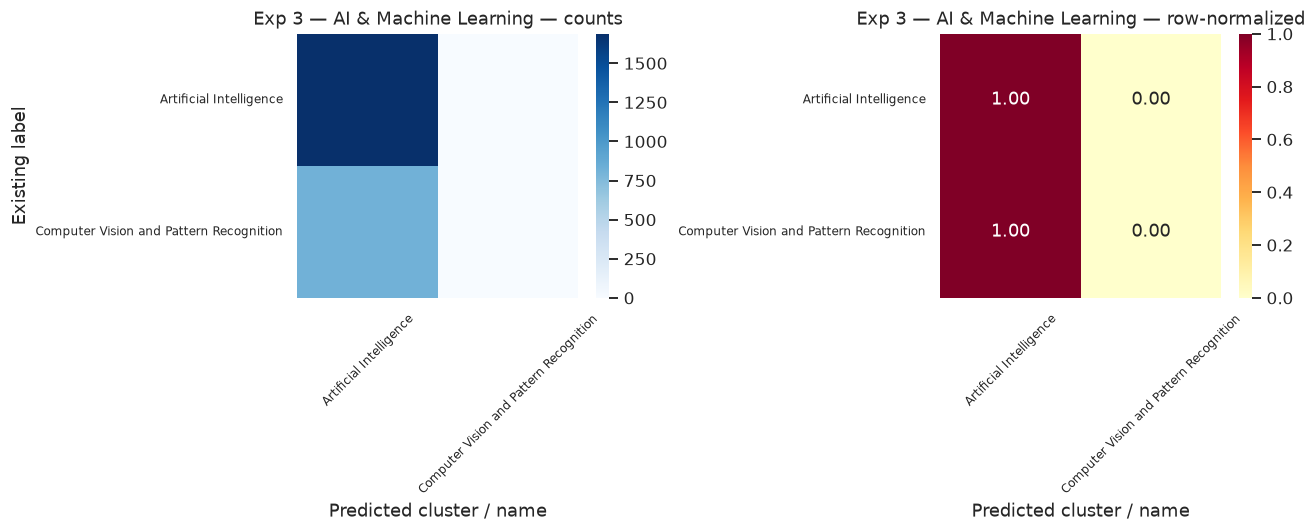

In [73]:
multi_leaf = [sd for sd, sfs in subdomain_map.items() if len(sfs) >= 2]
INSPECT_SUBDOMAIN = multi_leaf[0] if multi_leaf else None
print("Inspecting:", INSPECT_SUBDOMAIN)

if INSPECT_SUBDOMAIN:
    col = "cluster_within_" + INSPECT_SUBDOMAIN.replace(" ", "_").replace("&", "and")
    sub = work[work["taxonomy_subdomain"] == INSPECT_SUBDOMAIN]
    if col in work.columns and len(sub) > 0:
        # Map cluster → dominant subfield for readable axes
        named = (
            sub.groupby(col)[SUBFIELD_COLUMN]
            .agg(lambda s: s.mode().iloc[0] if s.notna().any() else "unknown")
        )
        y_pred_named = sub[col].map(named)
        plot_confusion(
            sub[SUBFIELD_COLUMN],
            y_pred_named,
            f"Exp 3 — {INSPECT_SUBDOMAIN}",
            OUTPUT_DIR / f"exp3_confusion_{INSPECT_SUBDOMAIN.replace(' ', '_').replace('&', 'and')}.png",
        )

---
# Summary

In [74]:
summary = pd.DataFrame([
    {
        "experiment": "1a subdomain match",
        "k": n_subdomains,
        "ari": exp1_subdomain["ari"],
        "nmi": exp1_subdomain["nmi"],
        "silhouette": exp1_subdomain_internal["silhouette"],
        "calinski_harabasz": exp1_subdomain_internal["calinski_harabasz"],
        "davies_bouldin": exp1_subdomain_internal["davies_bouldin"],
        "note": verdict_ari(exp1_subdomain["ari"]),
    },
    {
        "experiment": "1b subfield match",
        "k": n_subfields,
        "ari": exp1_subfield["ari"],
        "nmi": exp1_subfield["nmi"],
        "silhouette": exp1_subfield_internal["silhouette"],
        "calinski_harabasz": exp1_subfield_internal["calinski_harabasz"],
        "davies_bouldin": exp1_subfield_internal["davies_bouldin"],
        "note": verdict_ari(exp1_subfield["ari"]),
    },
    {
        "experiment": "2 natural k (consensus)",
        "k": natural["consensus"],
        "ari": np.nan,
        "nmi": np.nan,
        "silhouette": float(sweep_df.loc[sweep_df["k"] == natural["consensus"], "silhouette"].iloc[0]) if natural["consensus"] else np.nan,
        "calinski_harabasz": float(sweep_df.loc[sweep_df["k"] == natural["consensus"], "calinski_harabasz"].iloc[0]) if natural["consensus"] else np.nan,
        "davies_bouldin": float(sweep_df.loc[sweep_df["k"] == natural["consensus"], "davies_bouldin"].iloc[0]) if natural["consensus"] else np.nan,
        "note": f"votes sil={natural['silhouette_best']} CH={natural['ch_best']} DB={natural['db_best']}",
    },
])
summary.to_csv(OUTPUT_DIR / "summary.csv", index=False)

print("=" * 70)
print(f"Domain: {TARGET_DOMAIN}")
print("=" * 70)
print("\n[Exp 1] Taxonomy match (General excluded from scoring)")
print(f"  Subdomain k={n_subdomains}: ARI={exp1_subdomain['ari']:.3f} NMI={exp1_subdomain['nmi']:.3f}")
print(f"    → {verdict_ari(exp1_subdomain['ari'])}")
print(f"  Subfield  k={n_subfields}: ARI={exp1_subfield['ari']:.3f} NMI={exp1_subfield['nmi']:.3f}")
print(f"    → {verdict_ari(exp1_subfield['ari'])}")

print(f"\n[Exp 2] Natural groups: consensus k={natural['consensus']} "
      f"(taxonomy subdomain={n_subdomains}, subfield={n_subfields})")

print("\n[Exp 3] Within-subdomain suitability (excl. General):")
for _, r in within_df.iterrows():
    print(f"  • {r['subdomain']}: {r['verdict']}")

print(f"\nArtifacts → {OUTPUT_DIR.resolve()}")
summary

Domain: Computer Science

[Exp 1] Taxonomy match (General excluded from scoring)
  Subdomain k=6: ARI=0.106 NMI=0.181
    → POOR — taxonomy does not match text structure well
  Subfield  k=11: ARI=0.160 NMI=0.304
    → POOR — taxonomy does not match text structure well

[Exp 2] Natural groups: consensus k=15 (taxonomy subdomain=6, subfield=11)

[Exp 3] Within-subdomain suitability (excl. General):
  • AI & Machine Learning: PARTIAL — natural k matches taxonomy, but ARI weak
  • Software & Systems: SUITABLE — subfields match text & natural k
  • Networks & Security: N/A (1 subfield)
  • Theory & Computation: NOT SUITABLE — consider merging/splitting subfields
  • Graphics & HCI: NOT SUITABLE — consider merging/splitting subfields
  • Information Systems: N/A (1 subfield)

Artifacts → /home/asma/Projects/researchlanka-ai/backend/notebooks/outputs/domain_clustering/computer_science


,experiment,k,ari,nmi,silhouette,calinski_harabasz,davies_bouldin,note
0,1a subdomain match,6,0.105755,0.180795,0.054142,140.968849,3.973189,POOR — taxonomy does not match text structure ...
1,1b subfield match,11,0.160126,0.304327,0.071997,121.212659,3.425851,POOR — taxonomy does not match text structure ...
2,2 natural k (consensus),15,NaN,NaN,0.083546,109.655808,3.178557,votes sil=15 CH=2 DB=15


## t-SNE (optional visual check)

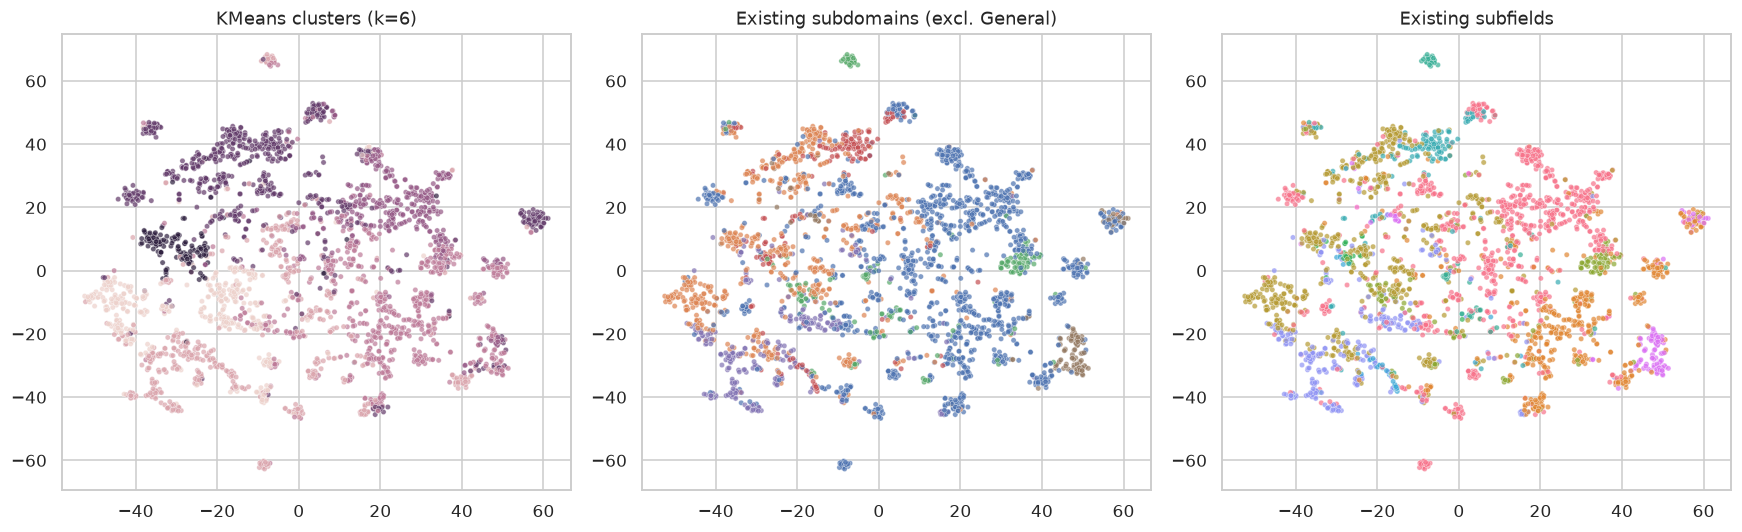

In [75]:
n_tsne = min(3000, len(X_embed))
rng = np.random.default_rng(RANDOM_STATE)
tsne_idx = rng.choice(len(X_embed), n_tsne, replace=False)
X_2d = TSNE(
    n_components=2,
    random_state=RANDOM_STATE,
    perplexity=min(30, n_tsne - 1),
).fit_transform(X_embed[tsne_idx])

plot_df = work.iloc[tsne_idx].copy()
plot_df["tsne_x"] = X_2d[:, 0]
plot_df["tsne_y"] = X_2d[:, 1]
# Hide General in the "existing" panel so structure of real groups is clearer
plot_df["taxonomy_subdomain_plot"] = plot_df["taxonomy_subdomain"].where(~plot_df["is_general"])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, title in [
    (axes[0], "cluster_subdomain", f"KMeans clusters (k={n_subdomains})"),
    (axes[1], "taxonomy_subdomain_plot", "Existing subdomains (excl. General)"),
    (axes[2], SUBFIELD_COLUMN, "Existing subfields"),
]:
    sns.scatterplot(data=plot_df, x="tsne_x", y="tsne_y", hue=col, ax=ax, s=12, alpha=0.7, legend=False)
    ax.set_title(title)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "tsne_overview.png", bbox_inches="tight")
plt.show()

## Export assignments

In [76]:
export_cols = [
    "title", DOMAIN_COLUMN, SUBFIELD_COLUMN,
    "taxonomy_subdomain", "is_general", "in_eval_taxonomy",
    "cluster_subdomain", "cluster_subdomain_name", "cluster_subfield",
]
export_cols += [c for c in work.columns if c.startswith("cluster_within_")]
export_cols = [c for c in export_cols if c in work.columns]

out_path = OUTPUT_DIR / f"clustered_{TARGET_DOMAIN.replace(' ', '_').lower()}.csv"
work[export_cols].to_csv(out_path, index=False)
print(f"Wrote {out_path}")
work[export_cols].head(8)

Wrote outputs/domain_clustering/computer_science/clustered_computer_science.csv


,title,primary_field,primary_subfield,taxonomy_subdomain,is_general,in_eval_taxonomy,cluster_subdomain,cluster_subdomain_name,cluster_subfield,cluster_within_AI_and_Machine_Learning,cluster_within_Software_and_Systems,cluster_within_Theory_and_Computation,cluster_within_Graphics_and_HCI
0,SymPy: symbolic computing in Python,Computer Science,Artificial Intelligence,AI & Machine Learning,False,True,1,AI & Machine Learning,7,1.0,NaN,NaN,NaN
1,FAIR Principles: Interpretations and Implement...,Computer Science,Information Systems,Information Systems,False,True,5,Information Systems,6,NaN,NaN,NaN,NaN
2,"Synthesis of a Vocal Sound from the 3,000 year...",Computer Science,Signal Processing,Theory & Computation,False,True,2,AI & Machine Learning,10,NaN,NaN,0.0,NaN
3,Online Delivery of Teaching and Laboratory Pra...,Computer Science,Computer Science Applications,Software & Systems,False,True,4,AI & Machine Learning,4,NaN,2.0,NaN,NaN
4,Survey on Multi-Access Edge Computing Security...,Computer Science,Computer Networks and Communications,Networks & Security,False,True,0,Information Systems,0,NaN,NaN,NaN,NaN
5,Neural Machine Translation for Low-resource La...,Computer Science,Artificial Intelligence,AI & Machine Learning,False,True,3,AI & Machine Learning,2,0.0,NaN,NaN,NaN
6,Semantic segmentation using Vision Transformer...,Computer Science,Computer Vision and Pattern Recognition,AI & Machine Learning,False,True,2,AI & Machine Learning,3,1.0,NaN,NaN,NaN
7,Real-time Credit Card Fraud Detection Using Ma...,Computer Science,Artificial Intelligence,AI & Machine Learning,False,True,0,Information Systems,6,1.0,NaN,NaN,NaN
